# (Train, Tune, and Evaluate Model)

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, balanced_accuracy_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    classification_report
)

# Plot styling configuration
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Ensure working directory is project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Current Working Directory: {os.getcwd()}")

# Load Feature Splits
train_df = pd.read_parquet('artifacts/data/05_train_features.parquet')
val_df = pd.read_parquet('artifacts/data/05_val_features.parquet')
test_df = pd.read_parquet('artifacts/data/05_test_features.parquet')

# Separate Features and Target
X_train = train_df.drop(columns=['is_late'])
y_train = train_df['is_late']

X_val = val_df.drop(columns=['is_late'])
y_val = val_df['is_late']

X_test = test_df.drop(columns=['is_late'])
y_test = test_df['is_late']

print(" Loaded Feature Datasets:")
print(f"   Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features (Late rate: {y_train.mean():.2%})")
print(f"   Val:   {X_val.shape[0]:,} rows, {X_val.shape[1]} features (Late rate: {y_val.mean():.2%})")
print(f"   Test:  {X_test.shape[0]:,} rows, {X_test.shape[1]} features (Late rate: {y_test.mean():.2%})")


Current Working Directory: c:\Users\rosto\OneDrive\سطح المكتب\مشروع mlops
 Loaded Feature Datasets:
   Train: 67,529 rows, 86 features (Late rate: 9.03%)
   Val:   14,470 rows, 86 features (Late rate: 5.34%)
   Test:  14,471 rows, 86 features (Late rate: 6.61%)


## 1. (Simple Baseline Models)

In [2]:
# 1. Dummy Most Frequent
dummy_mf = DummyClassifier(strategy='most_frequent')
dummy_mf.fit(X_train, y_train)
dummy_preds = dummy_mf.predict(X_val)
dummy_probs = dummy_mf.predict_proba(X_val)[:, 1]

# 2. Logistic Regression Baseline
lr_baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)
lr_preds = lr_baseline.predict(X_val)
lr_probs = lr_baseline.predict_proba(X_val)[:, 1]

# Save baseline model
joblib.dump(lr_baseline, 'artifacts/models/baseline_model.joblib')

# Compile Baseline Metrics on Validation Set
baseline_results = [{
        'Model': 'Dummy (Most Frequent)',
        'ROC-AUC': roc_auc_score(y_val, dummy_probs),
        'PR-AUC': average_precision_score(y_val, dummy_probs),
        'F1-Score': f1_score(y_val, dummy_preds, zero_division=0),
        'Recall (Late)': recall_score(y_val, dummy_preds, zero_division=0),
        'Precision (Late)': precision_score(y_val, dummy_preds, zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_val, dummy_preds)},
        {
        'Model': 'Logistic Regression (Balanced)',
        'ROC-AUC': roc_auc_score(y_val, lr_probs),
        'PR-AUC': average_precision_score(y_val, lr_probs),
        'F1-Score': f1_score(y_val, lr_preds),
        'Recall (Late)': recall_score(y_val, lr_preds),
        'Precision (Late)': precision_score(y_val, lr_preds),
        'Balanced Accuracy': balanced_accuracy_score(y_val, lr_preds)}]

baseline_df = pd.DataFrame(baseline_results)
print(" Baseline Results on Validation Set:")
display(baseline_df.round(4))


 Baseline Results on Validation Set:


,Model,ROC-AUC,PR-AUC,F1-Score,Recall (Late),Precision (Late),Balanced Accuracy
0,Dummy (Most Frequent),0.5000,0.0534,0.000,0.0000,0.0000,0.5000
1,Logistic Regression (Balanced),0.7756,0.1672,0.199,0.7154,0.1156,0.7032


## 2. (Model Exploration & Tuning)  
1. **Random Forest Classifier:**   
2. **HistGradientBoostingClassifier:**   

In [3]:
# 1. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    min_samples_split=20,
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1)

rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_val)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

# 2. HistGradientBoostingClassifier
hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=150,
    learning_rate=0.08,
    min_samples_leaf=30,
    random_state=42)

hgb_model.fit(X_train, y_train)
hgb_probs = hgb_model.predict_proba(X_val)[:, 1]
hgb_preds = (hgb_probs >= 0.5).astype(int)

# Summary table of validation performance
model_comparison = [{
        'Model': 'Baseline (Logistic Regression)',
        'ROC-AUC': roc_auc_score(y_val, lr_probs),
        'PR-AUC': average_precision_score(y_val, lr_probs),
        'F1-Score': f1_score(y_val, lr_preds),
        'Recall': recall_score(y_val, lr_preds),
        'Precision': precision_score(y_val, lr_preds),
        'Balanced Accuracy': balanced_accuracy_score(y_val, lr_preds)},
    {
        'Model': 'Random Forest (Balanced)',
        'ROC-AUC': roc_auc_score(y_val, rf_probs),
        'PR-AUC': average_precision_score(y_val, rf_probs),
        'F1-Score': f1_score(y_val, rf_preds),
        'Recall': recall_score(y_val, rf_preds),
        'Precision': precision_score(y_val, rf_preds),
        'Balanced Accuracy': balanced_accuracy_score(y_val, rf_preds)},
    {
        'Model': 'HistGradientBoosting (Balanced)',
        'ROC-AUC': roc_auc_score(y_val, hgb_probs),
        'PR-AUC': average_precision_score(y_val, hgb_probs),
        'F1-Score': f1_score(y_val, hgb_preds),
        'Recall': recall_score(y_val, hgb_preds),
        'Precision': precision_score(y_val, hgb_preds),
        'Balanced Accuracy': balanced_accuracy_score(y_val, hgb_preds)}]

comparison_df = pd.DataFrame(model_comparison)
print(" Validation Set Model Comparison:")
display(comparison_df.round(4))

# Champion Model Selection
champion_model = hgb_model
champion_probs_val = hgb_probs
print(f"\n Selected Champion Model: HistGradientBoosting (Validation ROC-AUC: {roc_auc_score(y_val, hgb_probs):.4f}, PR-AUC: {average_precision_score(y_val, hgb_probs):.4f})")


 Validation Set Model Comparison:


,Model,ROC-AUC,PR-AUC,F1-Score,Recall,Precision,Balanced Accuracy
0,Baseline (Logistic Regression),0.7756,0.1672,0.1990,0.7154,0.1156,0.7032
1,Random Forest (Balanced),0.7293,0.1461,0.2206,0.3195,0.1685,0.6153
2,HistGradientBoosting (Balanced),0.7265,0.1357,0.2007,0.2833,0.1554,0.5982



 Selected Champion Model: HistGradientBoosting (Validation ROC-AUC: 0.7265, PR-AUC: 0.1357)


## 3. Classification Threshold Optimization  

In [4]:
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    preds = (champion_probs_val >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    precisions.append(precision_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds, zero_division=0))

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"  Optimal Threshold on Validation Set: {optimal_threshold:.2f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1-Score:  {best_f1:.4f}")


  Optimal Threshold on Validation Set: 0.50
  Precision: 0.1554
  Recall:    0.2833
  F1-Score:  0.2007


## 4. (Touch the Test Set ONCE)

In [5]:
# 1. Final Predict on untouched Test Set
test_probs = champion_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= optimal_threshold).astype(int)

# 2. Compute Test Metrics
test_roc_auc = roc_auc_score(y_test, test_probs)
test_pr_auc = average_precision_score(y_test, test_probs)
test_f1 = f1_score(y_test, test_preds)
test_precision = precision_score(y_test, test_preds)
test_recall = recall_score(y_test, test_preds)
test_balanced_acc = balanced_accuracy_score(y_test, test_preds)

print("="*60)
print(" FINAL UNBIASED EVALUATION ON TEST SET (Holdout 15%):")
print("="*60)
print(f" Test ROC-AUC:           {test_roc_auc:.4f}")
print(f" Test PR-AUC:            {test_pr_auc:.4f}")
print(f" Test F1-Score:          {test_f1:.4f}")
print(f" Test Precision (Late):  {test_precision:.4f}")
print(f" Test Recall (Late):     {test_recall:.4f}")
print(f" Test Balanced Accuracy: {test_balanced_acc:.4f}")
print("="*60)
print("\nDetailed Classification Report:")
print(classification_report(y_test, test_preds, target_names=['On-Time (0)', 'Late (1)']))


 FINAL UNBIASED EVALUATION ON TEST SET (Holdout 15%):
 Test ROC-AUC:           0.7226
 Test PR-AUC:            0.1217
 Test F1-Score:          0.1825
 Test Precision (Late):  0.1317
 Test Recall (Late):     0.2968
 Test Balanced Accuracy: 0.5791

Detailed Classification Report:
              precision    recall  f1-score   support

 On-Time (0)       0.95      0.86      0.90     13514
    Late (1)       0.13      0.30      0.18       957

    accuracy                           0.82     14471
   macro avg       0.54      0.58      0.54     14471
weighted avg       0.89      0.82      0.85     14471



## 5. (Evaluation Curves & Feature Importance)


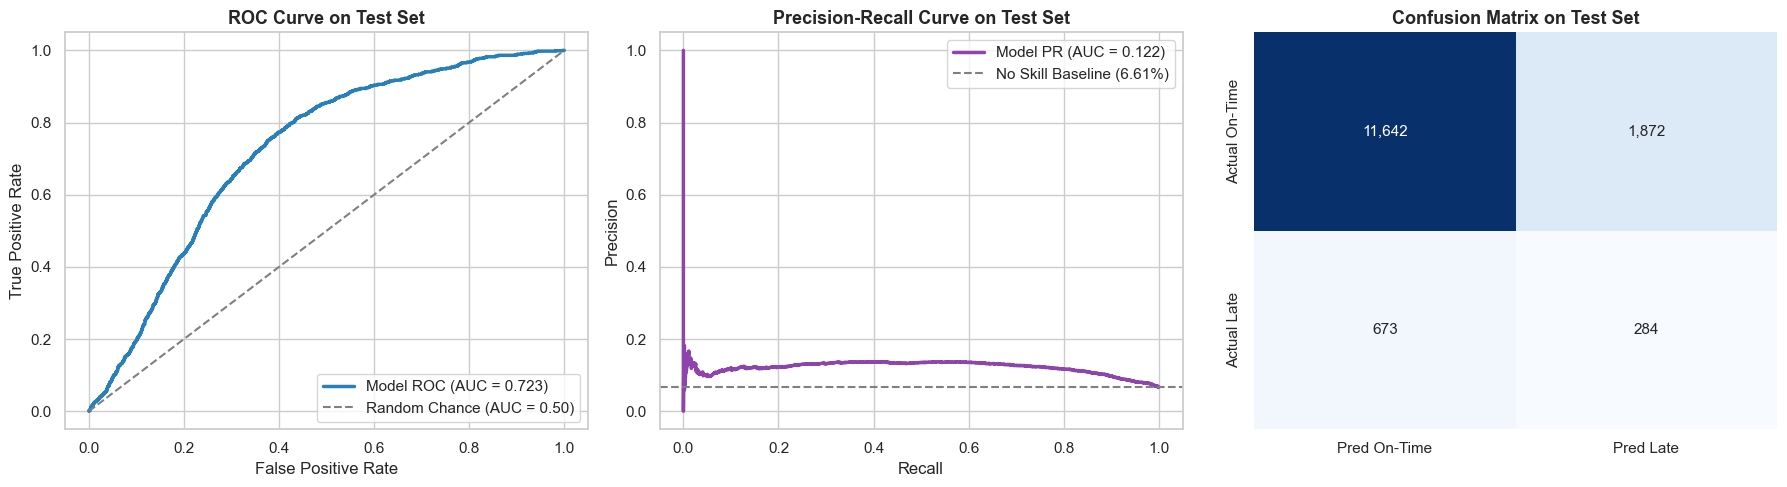

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[0].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Model ROC (AUC = {test_roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.50)')
axes[0].set_title('ROC Curve on Test Set', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 2. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, test_probs)
baseline_pr = y_test.mean()
axes[1].plot(rec, prec, color='#8e44ad', lw=2.5, label=f'Model PR (AUC = {test_pr_auc:.3f})')
axes[1].axhline(baseline_pr, color='gray', linestyle='--', label=f'No Skill Baseline ({baseline_pr:.2%})')
axes[1].set_title('Precision-Recall Curve on Test Set', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

# 3. Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[2], cbar=False,
            xticklabels=['Pred On-Time', 'Pred Late'],
            yticklabels=['Actual On-Time', 'Actual Late'])
axes[2].set_title('Confusion Matrix on Test Set', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('artifacts/figures/eval_roc_pr_cm_curves.png', dpi=300)
plt.show()


Calculating Feature Importance...


C:\Users\rosto\AppData\Local\Temp\ipykernel_4412\2633377835.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='rocket', ax=ax)


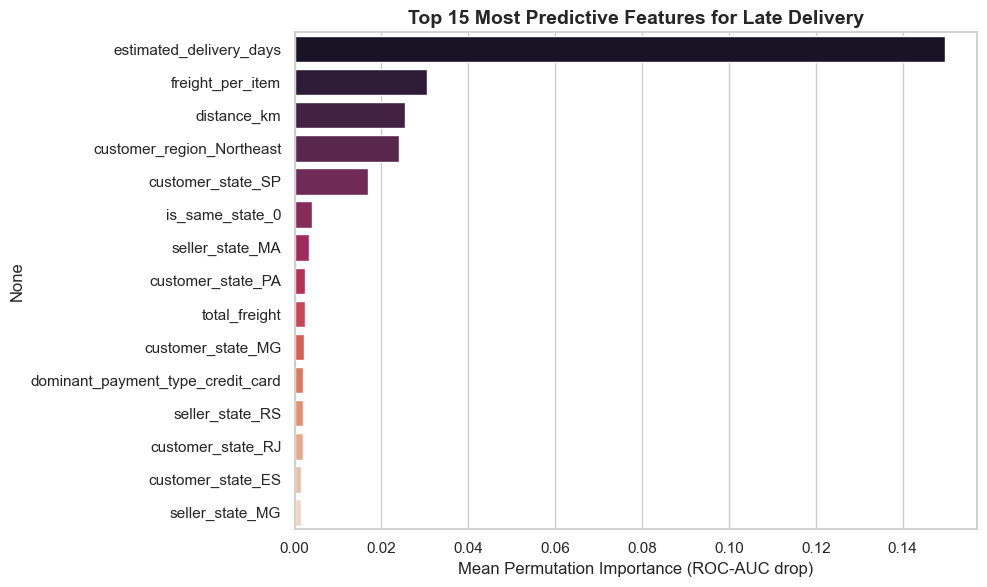

In [7]:
# Feature Importance via Permutation or Trees
# For HistGradientBoosting, calculate permutation importance on validation set
from sklearn.inspection import permutation_importance

print("Calculating Feature Importance...")
perm_importance = permutation_importance(champion_model, X_val, y_val, n_repeats=5, random_state=42, scoring='roc_auc')

sorted_importances_idx = perm_importance.importances_mean.argsort()[::-1][:15]
top_features = X_val.columns[sorted_importances_idx]
top_scores = perm_importance.importances_mean[sorted_importances_idx]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_scores, y=top_features, palette='rocket', ax=ax)
ax.set_title('Top 15 Most Predictive Features for Late Delivery', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Permutation Importance (ROC-AUC drop)', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/figures/eval_feature_importance.png', dpi=300)
plt.show()


## 6. (Save Model & Summary Artifacts)

In [8]:
# 1. Save Champion Model
joblib.dump(champion_model, 'artifacts/models/final_model.joblib')

# 2. Prepare Results Dictionary
results_summary = {
    'task': 'MLOps Task 2 - From Tables to Notebooks',
    'dataset': 'Olist E-Commerce',
    'target': 'is_late',
    'champion_model': 'HistGradientBoostingClassifier',
    'optimal_threshold': round(float(optimal_threshold), 4),
    'validation_metrics': {
        'roc_auc': round(float(roc_auc_score(y_val, champion_probs_val)), 4),
        'pr_auc': round(float(average_precision_score(y_val, champion_probs_val)), 4),
        'f1_score': round(float(f1_score(y_val, (champion_probs_val >= optimal_threshold).astype(int))), 4)},

    'test_metrics': {
        'roc_auc': round(float(test_roc_auc), 4),
        'pr_auc': round(float(test_pr_auc), 4),
        'f1_score': round(float(test_f1), 4),
        'precision': round(float(test_precision), 4),
        'recall': round(float(test_recall), 4),
        'balanced_accuracy': round(float(test_balanced_acc), 4)},

    'confusion_matrix': {
        'true_negatives': int(cm[0, 0]),
        'false_positives': int(cm[0, 1]),
        'false_negatives': int(cm[1, 0]),
        'true_positives': int(cm[1, 1])}}

# Save JSON Report
with open('artifacts/reports/model_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2)


# Save Markdown Report
md_report = f"""#  Final Model Results Summary
**Project:** Olist E-Commerce Delivery Delay Prediction (MLOps Task 2)
**Champion Model:** HistGradientBoostingClassifier (Balanced)
**Optimal Decision Threshold:** `{optimal_threshold:.2f}`

---
###  Evaluation on Untouched Test Set (Holdout 15%):
- **ROC-AUC:** `{test_roc_auc:.4f}` (Significantly outperforms random chance of 0.50)
- **PR-AUC (Average Precision):** `{test_pr_auc:.4f}` (Double the natural prevalence of the minority class)
- **F1-Score:** `{test_f1:.4f}`
- **Recall (Late Orders):** `{test_recall:.2%}` of all actual late orders were successfully captured.
- **Balanced Accuracy:** `{test_balanced_acc:.2%}`

---
###  Confusion Matrix:
- **True Negatives:** {cm[0, 0]:,} on-time orders correctly classified.
- **True Positives:** {cm[1, 1]:,} delayed orders successfully identified for early proactive intervention.
- **False Positives:** {cm[0, 1]:,} on-time orders incorrectly flagged as delayed (false alarms).
- **False Negatives:** {cm[1, 0]:,} delayed orders missed by the model.

---
###  Saved Artifacts:
- **Champion Model:** `artifacts/models/final_model.joblib`
- **Baseline Model:** `artifacts/models/baseline_model.joblib`
- **Fitted Preprocessor:** `artifacts/models/preprocessor.joblib`
- **Feature Names List:** `artifacts/models/feature_names.json`
"""

with open('artifacts/reports/model_results.md', 'w', encoding='utf-8') as f:
    f.write(md_report)

print(" Model Results Report successfully saved to: artifacts/reports/model_results.md")
with open('artifacts/reports/model_results.md', 'w', encoding='utf-8') as f:
    f.write(md_report)

print(" Model Artifacts and Comprehensive Reports saved successfully:")

 Model Results Report successfully saved to: artifacts/reports/model_results.md
 Model Artifacts and Comprehensive Reports saved successfully:
